# Notebook to make Figure 4: Event vs. data level PPC traces

In [1]:
import numpy as np 
import json 

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from matplotlib import style
style.use('../utils/plotting.mplstyle')
from matplotlib.lines import Line2D

import sys
sys.path.append('../utils')
import plot_utils 

## Setup

Load data

In [2]:
# Inferred population with the Gaussian model
pop_traces = np.load('../data/inferred_population_traces.npz', allow_pickle=True)['arr_0'].item()

# True underlying populations
ptrue = np.load('../data/true_underlying_population.npz', allow_pickle=True)['arr_0'].item()

# Predicted vs. Observed PPC traces 
eventlevel_predobs = np.load('../data/PPC_traces_event_level.npz', allow_pickle=True)['arr_0'].item()
datalevel_predobs = np.load('../data/PPC_traces_data_level.npz', allow_pickle=True)['arr_0'].item()

Get the fraction underpredicted for $\cos\theta$.

In [3]:
# This may take a minute. 
eventlevel_underpredicted = {
    ll:plot_utils.fraction_underpredicted(eventlevel_predobs[ll], ['costheta'])[1] for ll in eventlevel_predobs.keys()
}
datalevel_underpredicted = {
    ll:plot_utils.fraction_underpredicted(datalevel_predobs[ll], ['costheta'])[1] for ll in datalevel_predobs.keys()
}

Plotting labels, aesthetics, etc.

In [4]:
param='costheta'
costheta_grid = np.linspace(-1, 1, 200)
xticks = [-1, -.5, 0, .5, 1]
ntraces = 100
lims = [-1,1]

TITLE_FONTSIZE   = 30
AXISLABEL_FONTSIZE = 30
TICKLABEL_FONTSIZE = 25
LEGEND_FONTSIZE  = 27

plt.rcParams.update({
    "axes.titlesize": TITLE_FONTSIZE,
    "axes.labelsize": AXISLABEL_FONTSIZE,
    "xtick.labelsize": TICKLABEL_FONTSIZE,
    "ytick.labelsize": TICKLABEL_FONTSIZE,
    "legend.fontsize": LEGEND_FONTSIZE,
})

## Make figure

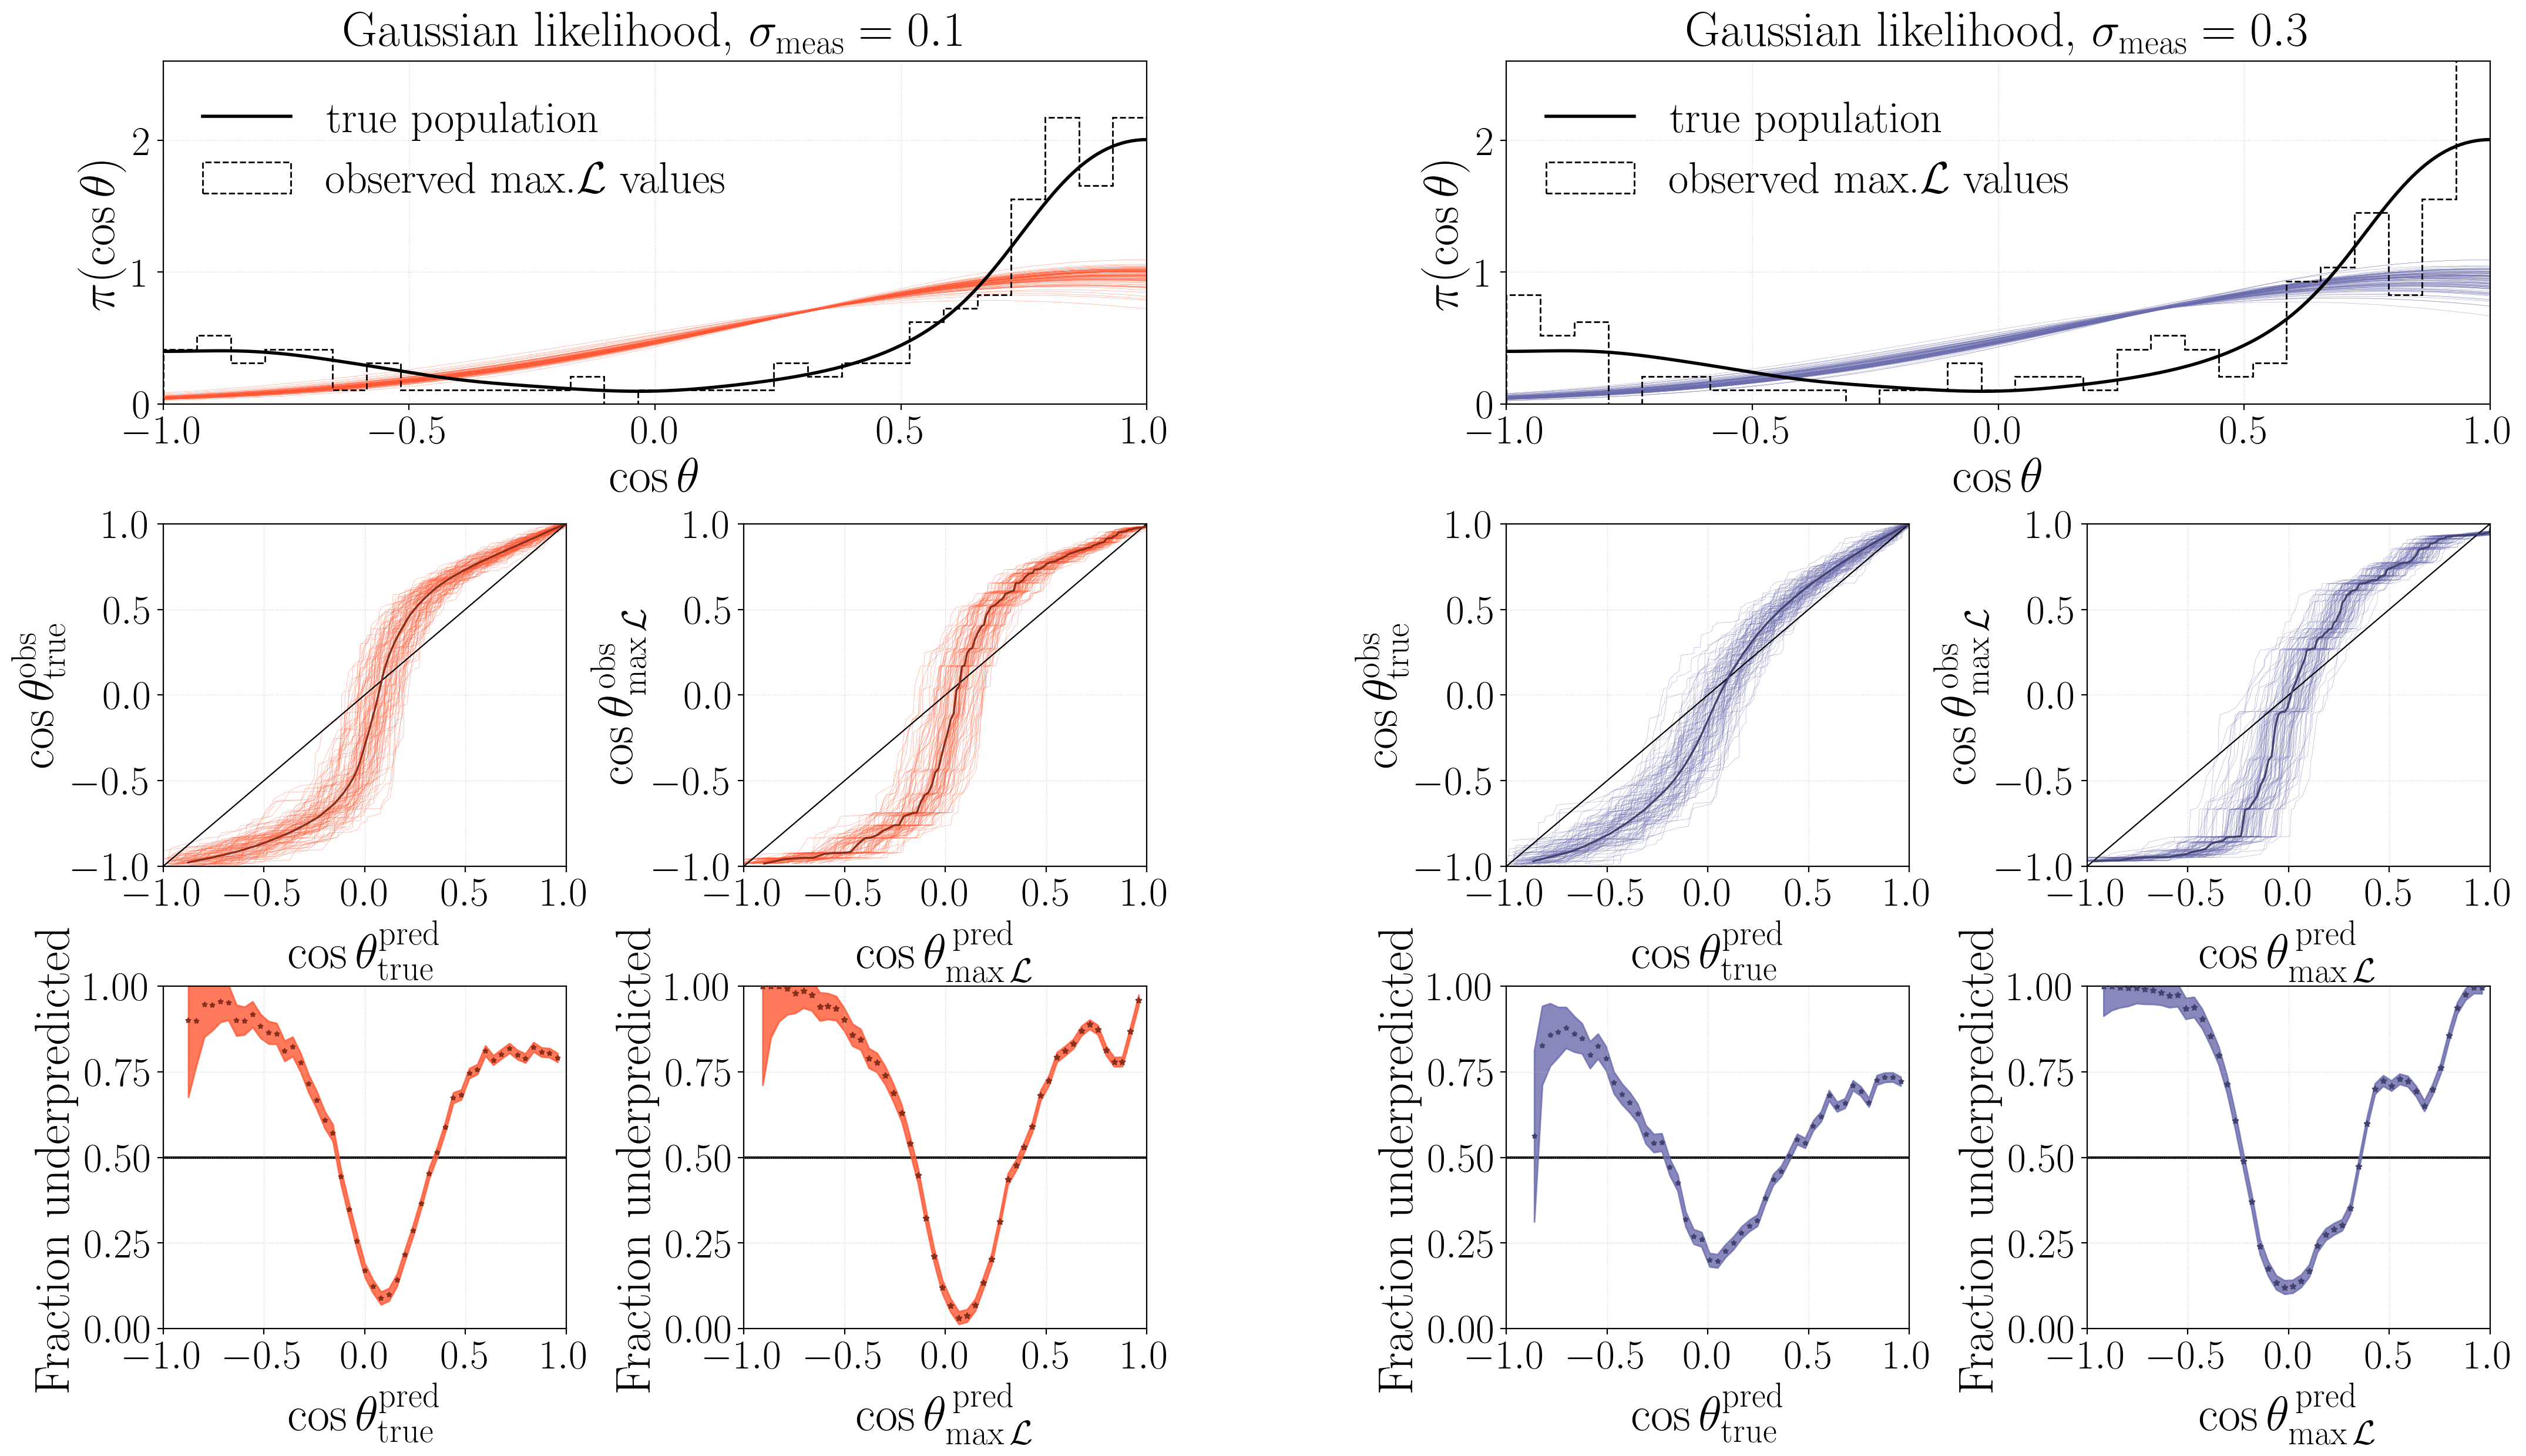

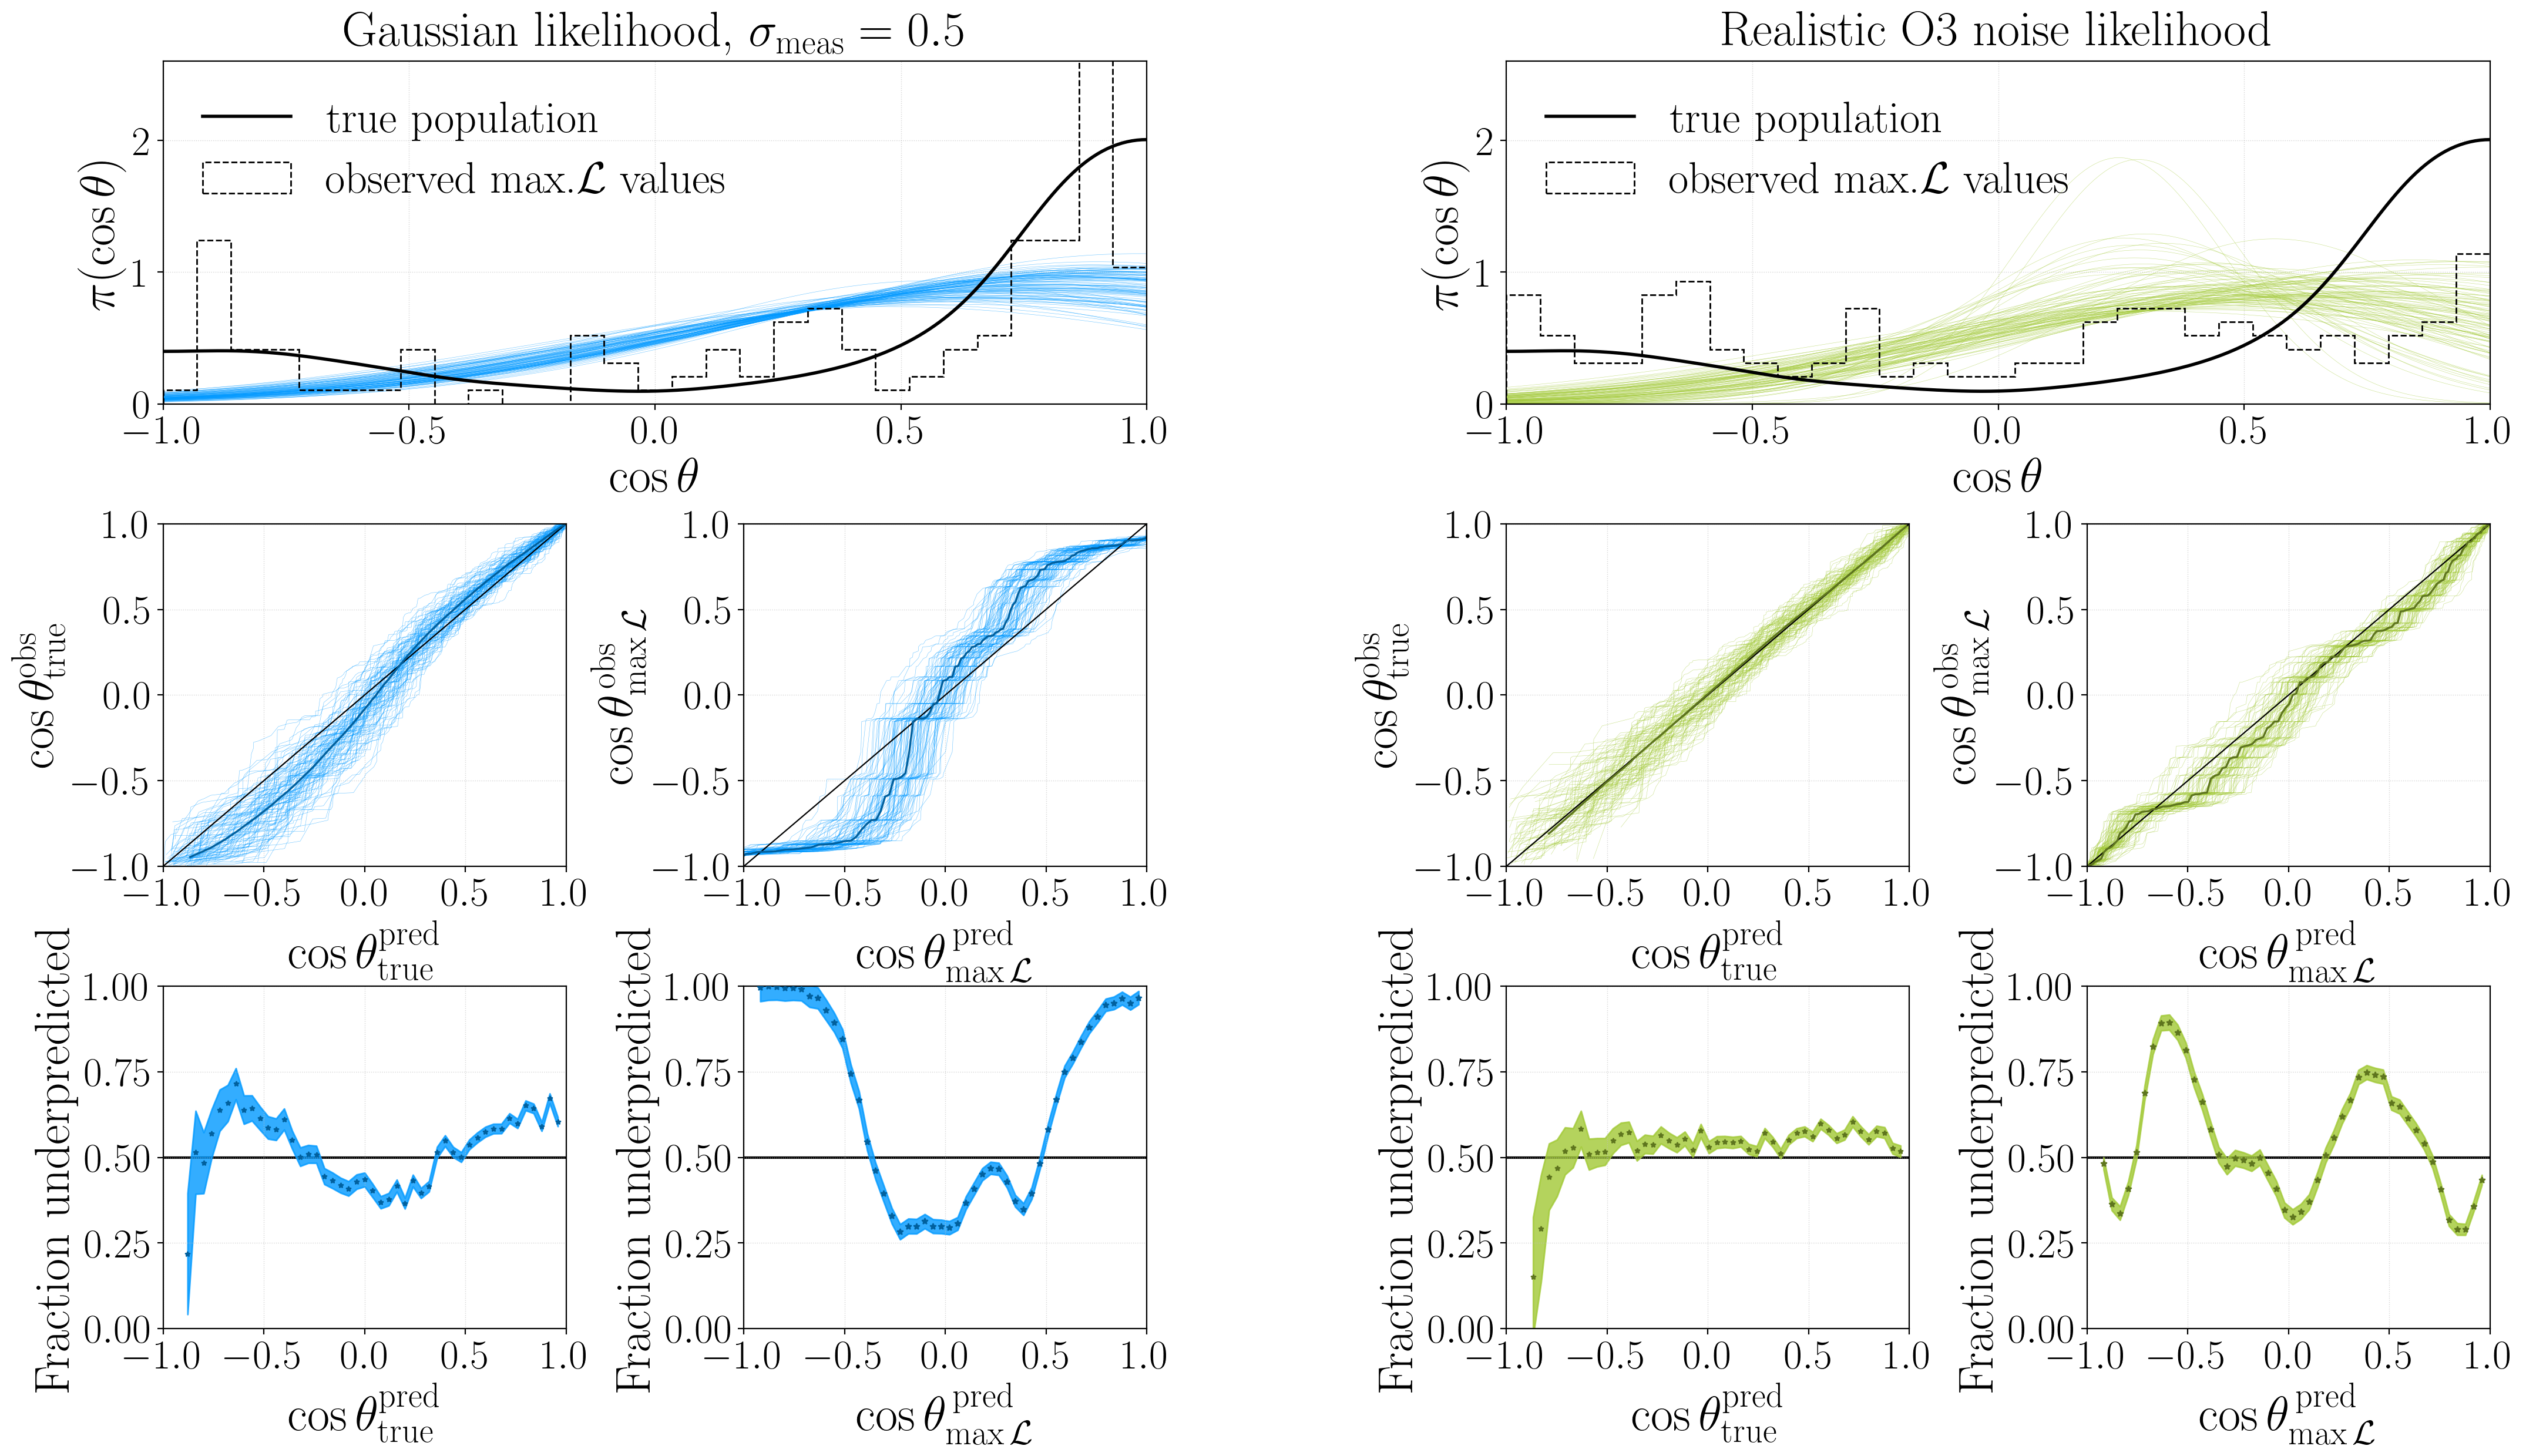

In [5]:
for row in [0,1]:

    if row == 0:
        posts = ['gaussian_likelihood_sigma_0.1', 'gaussian_likelihood_sigma_0.3']
        save_title = 'figure_04a'
    
    
    if row == 1:
        posts = ['gaussian_likelihood_sigma_0.5', 'bilby_likelihood']
        save_title = 'figure_04b'
    
    fig = plt.figure(figsize=(21.6, 12.5))
    gs = fig.add_gridspec(3, len(posts)*2 + 1, width_ratios=[1, 1, 0.01, 1, 1])   # added spacer column
    
    top_axes = []
    for j, post in enumerate(posts):
    
        start = j*2
        if start >= 2:
            start += 1   # shift right half past gap
    
        ax_top = fig.add_subplot(gs[0, start:start+2])  # span 2 columns
    
        # --- shrink width but keep centered ---
        pos = ax_top.get_position()
        new_width = pos.width * 0.85
        x0 = pos.x0 + (pos.width - new_width)/2.0
        ax_top.set_position([x0, pos.y0, new_width, pos.height])
        
        top_axes.append(ax_top)
    
    mid_axes = []
    bot_axes = []
    for j in range(len(posts)*2):
        col = j if j < 2 else j + 1
        mid_axes.append(fig.add_subplot(gs[1, col]))
        bot_axes.append(fig.add_subplot(gs[2, col]))
    
    
    # ======================
    # ===== TOP ROW ========
    # ======================
    toprow_ticks = [0, 1, 2]
    
    for j, post in enumerate(posts):
        ax_top = top_axes[j]
        ax_top.set_title(plot_utils.run_labels_full[post], pad=10)
        ax_top.set_xlabel(r'$\cos\theta$')
        ax_top.set_xticks(xticks)
        ax_top.set_ylim(0, 2.6)
        ax_top.set_xlim(-1, 1)
        ax_top.set_yticks(toprow_ticks)
        ax_top.tick_params(axis='both')
        ax_top.set_ylabel(r'$\pi(\cos\theta)$')

        # hyperposterior draws
        for n in range(ntraces):
            ax_top.plot(costheta_grid,
                        pop_traces[post][param][n, :],
                        color=plot_utils.run_colors[post], lw=.2, alpha=.6)
        # true population
        ax_top.plot(costheta_grid, ptrue[param],
                    lw=2, color='black',label='true population')

        # maxL obs histogram
        obs_maxL = np.sort(datalevel_predobs[post]['observed'][param].ravel())
        ax_top.hist(obs_maxL, density=True, histtype='step', ls='--', color='k', 
                    label=f'observed max.$\cal L$ values', bins=np.linspace(-1,1,30))
    
        ax_top.legend(loc='upper left', frameon=False)
    
    
    # ======================
    # ===== MIDDLE ROW =====
    # ======================
    for j, post in enumerate(posts):

        # event-level
        ax_mid_event = mid_axes[j*2]
        ax_mid_event.set_xticks(xticks)
        ax_mid_event.set_yticks(xticks)
        ax_mid_event.tick_params(axis='both')
        ax_mid_event.set_xlim(-1, 1)
        ax_mid_event.set_ylim(-1, 1)

        inds = np.arange(0, len(eventlevel_predobs[post]['predicted']['costheta1']), 1)
        randinds = np.random.choice(inds, size=100, replace=False)

        for ind in randinds:
            pred = np.sort(eventlevel_predobs[post]['predicted'][param][ind])
            obs = np.sort(eventlevel_predobs[post]['observed'][param][ind])
            ax_mid_event.plot(pred, obs, color=plot_utils.run_colors[post], lw=.2, alpha=.6)

        ax_mid_event.plot(lims, lims, lw=.8, color='black')

        allobs, pred_avgs = plot_utils.average_curve(eventlevel_predobs[post], param)
        ax_mid_event.plot(pred_avgs, allobs, lw=1.2, color=plot_utils.run_colors_darker[post])
        ax_mid_event.set_xlabel(r'$\cos\theta^{\rm pred}_{\rm true}$') 
        ax_mid_event.set_ylabel(r'$\cos\theta^{\rm obs}_{\rm true}$') 


        # data-level
        ax_mid_data = mid_axes[j*2+1]
        ax_mid_data.set_xlabel('Predicted $\cos\theta$')
        ax_mid_data.set_xticks(xticks)
        ax_mid_data.set_yticks(xticks)
        ax_mid_data.tick_params(axis='both')
        ax_mid_data.set_xlim(-1, 1)
        ax_mid_data.set_ylim(-1, 1)

        inds = np.arange(0, len(datalevel_predobs[post]['predicted']['costheta1']), 1)
        randinds = np.random.choice(inds, size=100, replace=False)

        for ind in randinds:
            pred = np.sort(datalevel_predobs[post]['predicted'][param][ind])
            obs = np.sort(datalevel_predobs[post]['observed'][param][ind])
            ax_mid_data.plot(pred, obs, color=plot_utils.run_colors[post], lw=.2, alpha=.6)

        ax_mid_data.plot(lims, lims, lw=.8, color='black')

        allobs, pred_avgs = plot_utils.average_curve(datalevel_predobs[post], param)
        ax_mid_data.plot(pred_avgs, allobs, lw=1.2, color=plot_utils.run_colors_darker[post])
        ax_mid_data.set_xlabel(r'$\cos\theta^{\, \rm pred}_{\rm max\, \mathcal L}$') 
        ax_mid_data.set_ylabel(r'$\cos\theta^{\, \rm obs}_{\rm max\, \mathcal L}$') 
    
    
    # ======================
    # ===== BOTTOM ROW =====
    # ======================
    for j, post in enumerate(posts):
    
        # event-level
        ax_bot_event = bot_axes[j*2]
        ax_bot_event.set_xlabel('Predicted $\cos\theta$')
        ax_bot_event.set_yticks([0, .25, 0.5, .75, 1])
        ax_bot_event.tick_params(axis='both')
    
        x = eventlevel_underpredicted[post][param]['xs'][1:-1]
        y = eventlevel_underpredicted[post][param]['fraction'][1:-1]
        err = 1/np.sqrt(eventlevel_underpredicted[post][param]['N'][1:-1])
    
        ax_bot_event.scatter(x, y, color=plot_utils.run_colors_darker[post], s=7, marker='*', zorder=5)
        ax_bot_event.fill_between(x, y+err, y-err, alpha=.8, color=plot_utils.run_colors[post])
        ax_bot_event.plot(lims, [.5, .5], zorder=-100, color='black')
    
        ax_bot_event.set_xlim(-1, 1)
        ax_bot_event.set_ylim(0, 1)
        ax_bot_event.set_xticks(xticks)
        ax_bot_event.set_xlabel(r'$\cos\theta^{\rm pred}_{\rm true}$') 
        ax_bot_event.set_ylabel('Fraction underpredicted') 
    
    
        # data-level
        ax_bot_data = bot_axes[j*2+1]
        ax_bot_data.set_xlabel('Predicted $\cos\theta$')
        ax_bot_data.set_xticks(xticks)
        ax_bot_data.set_yticks([0, .25, 0.5, .75, 1])
        ax_bot_data.tick_params(axis='both')
    
        x = datalevel_underpredicted[post][param]['xs'][1:-1]
        y = datalevel_underpredicted[post][param]['fraction'][1:-1]
        err = 1/np.sqrt(datalevel_underpredicted[post][param]['N'][1:-1])
    
        ax_bot_data.scatter(x, y, color=plot_utils.run_colors_darker[post], s=11, marker='*', zorder=5)
        ax_bot_data.fill_between(x, y+err, y-err, alpha=.8, color=plot_utils.run_colors[post])
        ax_bot_data.plot(lims, [.5, .5], zorder=-100, color='black')
    
        ax_bot_data.set_ylim(0, 1)
        ax_bot_data.set_xlim(-1, 1)
        ax_bot_data.set_xlabel(r'$\cos\theta^{\, \rm pred}_{\rm max\, \mathcal L}$') 
        ax_bot_data.set_ylabel(r'Fraction underpredicted') 
    
    plt.tight_layout()
    
    pos = ax_top.get_position()
    new_width = pos.width * 0.85
    x0 = pos.x0 + (pos.width - new_width)/2.0
    ax_top.set_position([x0, pos.y0, new_width, pos.height])

    for ax in [*top_axes, *mid_axes, *bot_axes]:
        ax.grid()
    
    fig.subplots_adjust(hspace=0.35, wspace=0.55)
    
    plt.savefig(f"{save_title}.png")